# 第6周：智能库存优化策略

基于销售数据，设计科学的库存管理策略。

## 模块清单
| 模块 | 内容 |
|------|------|
| 模块1 | ABC 库存分类 |
| 模块2 | 安全库存计算 |
| 模块3 | 经济订货批量 EOQ |
| 模块4 | 多周期库存优化（PuLP 线性规划）|
| 模块5 | 库存策略对比 |

## 交付物
- 库存优化代码
- ABC 分类结果报告
- 库存成本与服务水平对比表
- 未来 3 个月补货计划

## 模块1：ABC 库存分类

按销售额把 SKU 分成三类：
- **A 类**：累计销售额 0~70%，少数高价值 SKU，需重点管理
- **B 类**：累计 70~90%，中等价值
- **C 类**：累计 90~100%，多数低价值 SKU，可粗放管理

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 中文字体（Mac）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# ── 数据加载 ──
base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
df = pd.read_csv(base_path + 'amazon_daily_sales_train.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
print('数据加载完成：', len(df), '行 |', df['ProductID'].nunique(), '个 SKU')

# ── 1. 按 SKU 汇总总销售额、总销量、平均单价 ──
sku_summary = df.groupby('ProductID').agg(
    Category=('Category', 'first'),
    Total_Revenue=('TotalAmount', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
).reset_index()

# ── 2. 按销售额降序，计算累计占比 ──
sku_summary = sku_summary.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
sku_summary['Revenue_Share'] = sku_summary['Total_Revenue'] / sku_summary['Total_Revenue'].sum()
sku_summary['Cumulative_Share'] = sku_summary['Revenue_Share'].cumsum()

# ── 3. ABC 分类：A=0~70%，B=70~90%，C=90~100% ──
def abc_label(cum):
    if cum <= 0.70:
        return 'A'
    elif cum <= 0.90:
        return 'B'
    else:
        return 'C'

sku_summary['ABC_Class'] = sku_summary['Cumulative_Share'].apply(abc_label)

# ── 4. 分类汇总统计 ──
abc_stat = sku_summary.groupby('ABC_Class').agg(
    SKU数量=('ProductID', 'count'),
    销售额合计=('Total_Revenue', 'sum'),
).reset_index()
abc_stat['SKU占比%'] = (abc_stat['SKU数量'] / abc_stat['SKU数量'].sum() * 100).round(1)
abc_stat['销售额占比%'] = (abc_stat['销售额合计'] / abc_stat['销售额合计'].sum() * 100).round(1)

print('\n===== ABC 分类汇总 =====')
print(abc_stat.to_string(index=False))

数据加载完成： 48539 行 | 50 个 SKU

===== ABC 分类汇总 =====
ABC_Class  SKU数量       销售额合计  SKU占比%  销售额占比%
        A     34 50749935.94    68.0    69.0
        B     10 14343200.93    20.0    19.5
        C      6  8436209.48    12.0    11.5


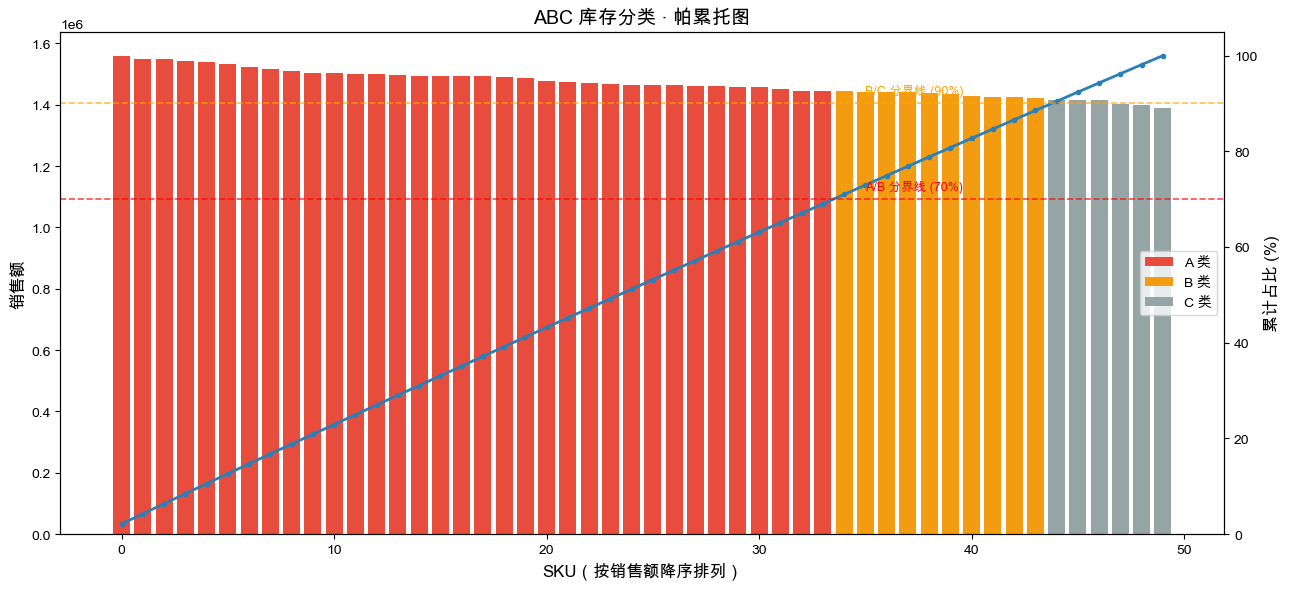

帕累托图已保存：reports/fig_w6_01_abc_pareto.png


In [2]:
# ── 5. 绘制帕累托图（ABC 分类可视化）──
fig, ax1 = plt.subplots(figsize=(13, 6))

x = range(len(sku_summary))
colors = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#95a5a6'}
bar_colors = [colors[c] for c in sku_summary['ABC_Class']]

# 左轴：每个 SKU 的销售额柱状图
ax1.bar(x, sku_summary['Total_Revenue'], color=bar_colors, width=0.8)
ax1.set_xlabel('SKU（按销售额降序排列）', fontsize=12)
ax1.set_ylabel('销售额', fontsize=12)
ax1.set_title('ABC 库存分类 · 帕累托图', fontsize=14, fontweight='bold')

# 右轴：累计占比曲线
ax2 = ax1.twinx()
ax2.plot(x, sku_summary['Cumulative_Share'] * 100, color='#2980b9',
         linewidth=2, marker='o', markersize=3, label='累计销售额占比')
ax2.set_ylabel('累计占比 (%)', fontsize=12)
ax2.set_ylim(0, 105)

# 70% 和 90% 分界线
ax2.axhline(70, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.axhline(90, color='orange', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(len(x)*0.7, 72, 'A/B 分界线 (70%)', color='red', fontsize=9)
ax2.text(len(x)*0.7, 92, 'B/C 分界线 (90%)', color='orange', fontsize=9)

# 图例（用色块说明 ABC）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['A'], label='A 类'),
                   Patch(facecolor=colors['B'], label='B 类'),
                   Patch(facecolor=colors['C'], label='C 类')]
ax1.legend(handles=legend_elements, loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_w6_01_abc_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('帕累托图已保存：reports/fig_w6_01_abc_pareto.png')

In [3]:
# ── 6. 导出 ABC 分类结果 ──
abc_output = sku_summary[[
    'ProductID', 'Category', 'Total_Revenue', 'Total_Quantity',
    'Avg_UnitPrice', 'Revenue_Share', 'Cumulative_Share', 'ABC_Class'
]].copy()

# 数值保留合理小数位
abc_output['Total_Revenue']    = abc_output['Total_Revenue'].round(2)
abc_output['Avg_UnitPrice']    = abc_output['Avg_UnitPrice'].round(2)
abc_output['Revenue_Share']    = (abc_output['Revenue_Share'] * 100).round(2)
abc_output['Cumulative_Share'] = (abc_output['Cumulative_Share'] * 100).round(2)

# 保存为 CSV（供后续模块使用）
abc_csv_path = base_path + 'abc_classification.csv'
abc_output.to_csv(abc_csv_path, index=False, encoding='utf-8-sig')
print('ABC 分类结果已导出：', abc_csv_path)
print('共', len(abc_output), '个 SKU\n')

# 预览前 10 行
print('===== ABC 分类结果预览（前10个 SKU）=====')
print(abc_output.head(10).to_string(index=False))

ABC 分类结果已导出： /Users/huyujie/Documents/amazon-supply-chain-project/data/processed/abc_classification.csv
共 50 个 SKU

===== ABC 分类结果预览（前10个 SKU）=====
ProductID          Category  Total_Revenue  Total_Quantity  Avg_UnitPrice  Revenue_Share  Cumulative_Share ABC_Class
   P00047      Toys & Games     1560251.29            5014         310.90           2.12              2.12         A
   P00031 Sports & Outdoors     1550558.88            4961         308.22           2.11              4.23         A
   P00007          Clothing     1547869.83            4985         307.66           2.11              6.34         A
   P00010          Clothing     1541291.08            4867         311.24           2.10              8.43         A
   P00019          Clothing     1540839.40            5081         295.92           2.10             10.53         A
   P00017 Sports & Outdoors     1533432.47            4974         299.18           2.09             12.61         A
   P00006      Toys & Games     1

### 模块1 小结

- 采用经典 ABC 分类法，按累计销售额占比划分：A 类（0~70%）、B 类（70~90%）、C 类（90~100%）。
- 分类结果已导出为 `abc_classification.csv`，供后续安全库存、EOQ、补货优化模块使用。
- **数据说明**：本数据集 SKU 数量较少，各 SKU 销售额分布较为均匀，因此 A 类 SKU 占比偏高。在真实大规模商品库中，A 类通常仅占少数 SKU 却贡献绝大部分销售额（典型的「二八分布」）。后续库存策略仍按 A/B/C 分级管理：A 类高频盘点、高服务水平；C 类粗放管理、低持库成本。

## 模块2：安全库存计算

安全库存用于应对需求波动和提前期内的不确定性，避免缺货。

**计算公式**：
$$安全库存 = Z_{服务水平} \times \sigma_{日需求} \times \sqrt{提前期}$$

- **Z 值**：服务水平对应的正态分布分位数（90%→1.28，95%→1.65，99%→2.33）
- **σ**：日需求的标准差，反映需求波动程度
- **提前期**：从下单到到货的天数，本项目设为 7 天

服务水平越高 → 备货越多 → 缺货风险越低，但持库成本越高。

In [4]:
from scipy import stats

# ── 参数设定 ──
LEAD_TIME = 7   # 提前期（天）
SERVICE_LEVELS = {'90%': 0.90, '95%': 0.95, '99%': 0.99}

# 读入模块1的 ABC 分类结果
abc = pd.read_csv(base_path + 'abc_classification.csv')

# ── 计算每个 SKU 的日需求统计 + 安全库存 ──
date_range = pd.date_range(df['OrderDate'].min(), df['OrderDate'].max(), freq='D')

rows = []
for pid in abc['ProductID']:
    # 该 SKU 的日销量序列（缺失日期补 0）
    s = df[df['ProductID'] == pid].groupby('OrderDate')['Quantity'].sum()
    s = s.reindex(date_range, fill_value=0)

    mean_d = s.mean()   # 日均需求
    std_d  = s.std()    # 日需求标准差

    r = {'ProductID': pid, 'Daily_Mean': round(mean_d, 2), 'Daily_Std': round(std_d, 2)}

    # 三档服务水平下的安全库存
    for name, sl in SERVICE_LEVELS.items():
        z = stats.norm.ppf(sl)                       # 服务水平对应 Z 值
        ss = z * std_d * np.sqrt(LEAD_TIME)          # 安全库存公式
        r[f'SafetyStock_{name}'] = round(max(ss, 0), 1)

    rows.append(r)

safety_stock_df = pd.DataFrame(rows)

# 合并 ABC 分类信息
safety_stock_df = safety_stock_df.merge(
    abc[['ProductID', 'Category', 'ABC_Class']], on='ProductID')

print('安全库存计算完成，共', len(safety_stock_df), '个 SKU\n')
print('===== 安全库存计算结果（前 8 个 SKU）=====')
print(safety_stock_df.head(8).to_string(index=False))

安全库存计算完成，共 50 个 SKU

===== 安全库存计算结果（前 8 个 SKU）=====
ProductID  Daily_Mean  Daily_Std  SafetyStock_90%  SafetyStock_95%  SafetyStock_99%          Category ABC_Class
   P00047        3.44       3.46             11.7             15.1             21.3      Toys & Games         A
   P00031        3.40       3.64             12.3             15.8             22.4 Sports & Outdoors         A
   P00007        3.42       3.64             12.3             15.8             22.4          Clothing         A
   P00010        3.34       3.41             11.6             14.8             21.0          Clothing         A
   P00019        3.48       3.62             12.3             15.8             22.3          Clothing         A
   P00017        3.41       3.58             12.1             15.6             22.0 Sports & Outdoors         A
   P00006        3.35       3.42             11.6             14.9             21.1      Toys & Games         A
   P00037        3.45       3.69             12.5   

===== 各 ABC 类别平均安全库存 =====
           SafetyStock_90%  SafetyStock_95%  SafetyStock_99%
ABC_Class                                                   
A                     11.9             15.2             21.5
B                     11.5             14.8             20.9
C                     11.5             14.8             20.9


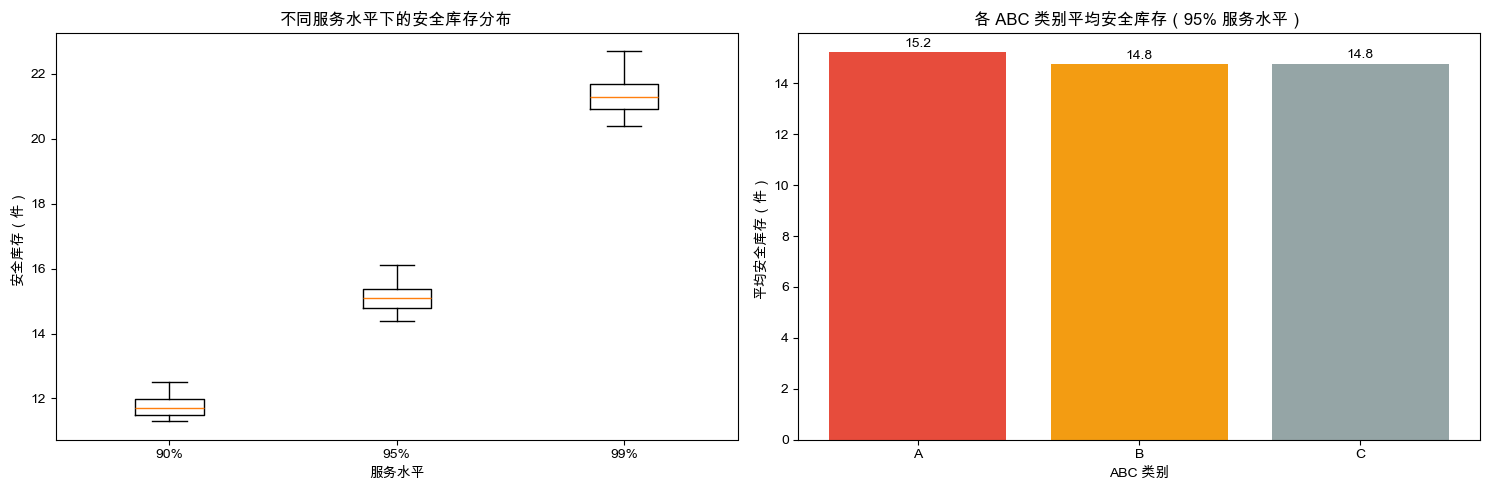


安全库存图已保存：reports/fig_w6_02_safety_stock.png


In [6]:
# ── 按 ABC 类别汇总平均安全库存 ──
ss_by_abc = safety_stock_df.groupby('ABC_Class')[
    ['SafetyStock_90%', 'SafetyStock_95%', 'SafetyStock_99%']].mean().round(1)
print('===== 各 ABC 类别平均安全库存 =====')
print(ss_by_abc.to_string())

# ── 可视化：三档服务水平下的安全库存对比 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：各服务水平下的安全库存分布（箱线图）
ss_long = safety_stock_df.melt(
    id_vars=['ProductID', 'ABC_Class'],
    value_vars=['SafetyStock_90%', 'SafetyStock_95%', 'SafetyStock_99%'],
    var_name='服务水平', value_name='安全库存')
ss_long['服务水平'] = ss_long['服务水平'].str.replace('SafetyStock_', '')

axes[0].boxplot(
    [ss_long[ss_long['服务水平'] == sl]['安全库存'] for sl in ['90%', '95%', '99%']],
    tick_labels=['90%', '95%', '99%'])
axes[0].set_title('不同服务水平下的安全库存分布', fontsize=12, fontweight='bold')
axes[0].set_xlabel('服务水平')
axes[0].set_ylabel('安全库存（件）')

# 右图：各 ABC 类别在 95% 服务水平下的平均安全库存
colors = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#95a5a6'}
abc_order = ['A', 'B', 'C']
means_95 = [safety_stock_df[safety_stock_df['ABC_Class'] == c]['SafetyStock_95%'].mean()
            for c in abc_order]
bars = axes[1].bar(abc_order, means_95, color=[colors[c] for c in abc_order])
for bar, v in zip(bars, means_95):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_title('各 ABC 类别平均安全库存（95% 服务水平）', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ABC 类别')
axes[1].set_ylabel('平均安全库存（件）')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_w6_02_safety_stock.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('\n安全库存图已保存：reports/fig_w6_02_safety_stock.png')

In [7]:
# ── 导出安全库存计算结果 ──
ss_csv_path = base_path + 'safety_stock.csv'
safety_stock_df.to_csv(ss_csv_path, index=False, encoding='utf-8-sig')
print('安全库存结果已导出：', ss_csv_path)
print('共', len(safety_stock_df), '个 SKU')

# 预览
print('\n===== 安全库存结果预览（前 10 个 SKU）=====')
print(safety_stock_df.head(10).to_string(index=False))

安全库存结果已导出： /Users/huyujie/Documents/amazon-supply-chain-project/data/processed/safety_stock.csv
共 50 个 SKU

===== 安全库存结果预览（前 10 个 SKU）=====
ProductID  Daily_Mean  Daily_Std  SafetyStock_90%  SafetyStock_95%  SafetyStock_99%          Category ABC_Class
   P00047        3.44       3.46             11.7             15.1             21.3      Toys & Games         A
   P00031        3.40       3.64             12.3             15.8             22.4 Sports & Outdoors         A
   P00007        3.42       3.64             12.3             15.8             22.4          Clothing         A
   P00010        3.34       3.41             11.6             14.8             21.0          Clothing         A
   P00019        3.48       3.62             12.3             15.8             22.3          Clothing         A
   P00017        3.41       3.58             12.1             15.6             22.0 Sports & Outdoors         A
   P00006        3.35       3.42             11.6             14.9          

### 模块2 小结

- 基于各 SKU 的日需求标准差，计算了 90%、95%、99% 三档服务水平下的安全库存。
- 服务水平越高，所需安全库存越多——这是「服务水平」与「持库成本」之间的权衡。
- 结果已导出为 `safety_stock.csv`，将与后续 EOQ、补货计划模块结合使用。
- **分级策略建议**：A 类 SKU 直接影响营收，建议采用 95%~99% 高服务水平；C 类 SKU 价值较低，可采用 90% 服务水平以降低持库成本。

## 模块3：经济订货批量 EOQ

EOQ（Economic Order Quantity）回答一个问题：**每次订货订多少最省钱？**

- 订货量大 → 订货次数少（省订货成本），但库存高（持库成本高）
- 订货量小 → 库存低（省持库成本），但订货频繁（订货成本高）

EOQ 就是让「年订货成本 + 年持库成本」总和最小的订货量。

**计算公式**：
$$EOQ = \sqrt{\frac{2 \times 年需求量 \times 单次订货成本}{单位年持库成本}}$$

**参数假设**：
- 单次订货成本：50 元/次
- 年持库成本率：占商品单价的 25%

In [8]:
# ── 参数假设 ──
ORDER_COST   = 50.0    # 单次订货成本（元/次）
HOLDING_RATE = 0.25    # 年持库成本率（占商品单价的比例）

# 把数据天数换算成「年」，用于估算年需求量
n_days = (df['OrderDate'].max() - df['OrderDate'].min()).days + 1
year_factor = 365.0 / n_days
print(f'数据覆盖 {n_days} 天，年化系数 = {year_factor:.3f}\n')

# ── 逐个 SKU 计算 EOQ ──
rows = []
for pid in abc['ProductID']:
    sub = df[df['ProductID'] == pid]

    total_q       = sub['Quantity'].sum()
    annual_demand = total_q * year_factor          # 年需求量
    unit_price    = sub['UnitPrice'].mean()        # 平均单价
    holding_unit  = unit_price * HOLDING_RATE      # 单位年持库成本

    if holding_unit > 0:
        eoq         = np.sqrt(2 * annual_demand * ORDER_COST / holding_unit)
        n_orders    = annual_demand / eoq          # 年订货次数
        order_cost  = n_orders * ORDER_COST        # 年订货成本
        holding_cost= (eoq / 2) * holding_unit     # 年持库成本（平均库存=EOQ/2）
        total_cost  = order_cost + holding_cost    # 年总成本
    else:
        eoq = n_orders = order_cost = holding_cost = total_cost = 0

    rows.append({
        'ProductID'        : pid,
        'Annual_Demand'    : round(annual_demand, 0),
        'Unit_Price'       : round(unit_price, 2),
        'EOQ'              : round(eoq, 0),
        'Orders_Per_Year'  : round(n_orders, 1),
        'Order_Cost'       : round(order_cost, 2),
        'Holding_Cost'     : round(holding_cost, 2),
        'Total_Annual_Cost': round(total_cost, 2),
    })

eoq_df = pd.DataFrame(rows).merge(abc[['ProductID', 'Category', 'ABC_Class']], on='ProductID')

print('EOQ 计算完成，共', len(eoq_df), '个 SKU\n')
print('===== EOQ 计算结果（前 8 个 SKU）=====')
print(eoq_df.head(8).to_string(index=False))

数据覆盖 1459 天，年化系数 = 0.250

EOQ 计算完成，共 50 个 SKU

===== EOQ 计算结果（前 8 个 SKU）=====
ProductID  Annual_Demand  Unit_Price  EOQ  Orders_Per_Year  Order_Cost  Holding_Cost  Total_Annual_Cost          Category ABC_Class
   P00047         1254.0      310.90 40.0             31.2     1561.21       1561.21            3122.41      Toys & Games         A
   P00031         1241.0      308.22 40.0             30.9     1546.23       1546.23            3092.46 Sports & Outdoors         A
   P00007         1247.0      307.66 40.0             31.0     1548.55       1548.55            3097.09          Clothing         A
   P00010         1218.0      311.24 40.0             30.8     1538.98       1538.98            3077.97          Clothing         A
   P00019         1271.0      295.92 41.0             30.7     1533.28       1533.28            3066.57          Clothing         A
   P00017         1244.0      299.18 41.0             30.5     1525.39       1525.39            3050.78 Sports & Outdoors         

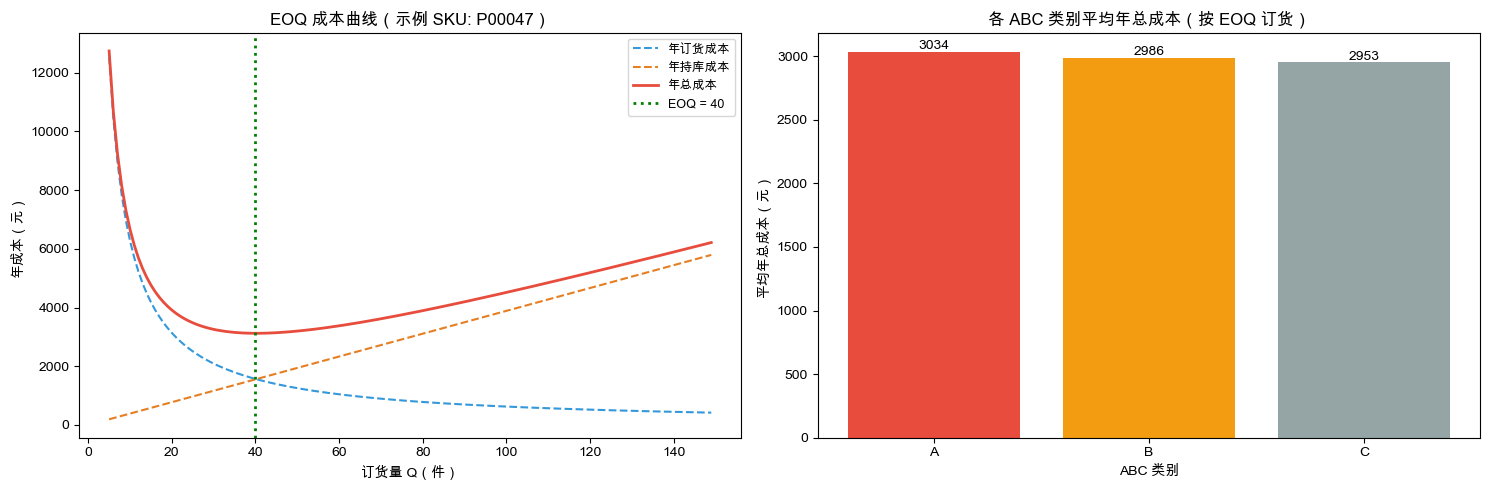

EOQ 图已保存：reports/fig_w6_03_eoq.png


In [9]:
# ── 可视化 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：以一个代表性 SKU 为例，画 EOQ 成本曲线
sample_sku = eoq_df.iloc[0]
unit_price = sample_sku['Unit_Price']
annual_demand = sample_sku['Annual_Demand']
holding_unit = unit_price * HOLDING_RATE

q_range = np.arange(5, 150, 1)
order_costs   = annual_demand / q_range * ORDER_COST      # 订货成本随 Q 下降
holding_costs = q_range / 2 * holding_unit                # 持库成本随 Q 上升
total_costs   = order_costs + holding_costs               # 总成本（U 形曲线）

axes[0].plot(q_range, order_costs, '--', color='#3498db', label='年订货成本')
axes[0].plot(q_range, holding_costs, '--', color='#e67e22', label='年持库成本')
axes[0].plot(q_range, total_costs, '-', color='#e74c3c', linewidth=2, label='年总成本')
axes[0].axvline(sample_sku['EOQ'], color='green', linestyle=':', linewidth=2,
                label=f"EOQ = {sample_sku['EOQ']:.0f}")
axes[0].set_title(f"EOQ 成本曲线（示例 SKU: {sample_sku['ProductID']}）",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('订货量 Q（件）')
axes[0].set_ylabel('年成本（元）')
axes[0].legend(fontsize=9)

# 右图：各 ABC 类别的平均年总成本
colors = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#95a5a6'}
abc_order = ['A', 'B', 'C']
cost_means = [eoq_df[eoq_df['ABC_Class'] == c]['Total_Annual_Cost'].mean()
              for c in abc_order]
bars = axes[1].bar(abc_order, cost_means, color=[colors[c] for c in abc_order])
for bar, v in zip(bars, cost_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:.0f}', ha='center', fontweight='bold')
axes[1].set_title('各 ABC 类别平均年总成本（按 EOQ 订货）', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ABC 类别')
axes[1].set_ylabel('平均年总成本（元）')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_w6_03_eoq.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('EOQ 图已保存：reports/fig_w6_03_eoq.png')

In [10]:
# ── 导出 EOQ 计算结果 ──
eoq_csv_path = base_path + 'eoq_results.csv'
eoq_df.to_csv(eoq_csv_path, index=False, encoding='utf-8-sig')
print('EOQ 结果已导出：', eoq_csv_path)
print('共', len(eoq_df), '个 SKU')

# 按 ABC 类别汇总
eoq_by_abc = eoq_df.groupby('ABC_Class').agg(
    SKU数量=('ProductID', 'count'),
    平均EOQ=('EOQ', 'mean'),
    平均年订货次数=('Orders_Per_Year', 'mean'),
    平均年总成本=('Total_Annual_Cost', 'mean'),
).round(1)
print('\n===== 各 ABC 类别 EOQ 汇总 =====')
print(eoq_by_abc.to_string())

EOQ 结果已导出： /Users/huyujie/Documents/amazon-supply-chain-project/data/processed/eoq_results.csv
共 50 个 SKU

===== 各 ABC 类别 EOQ 汇总 =====
           SKU数量  平均EOQ  平均年订货次数  平均年总成本
ABC_Class                               
A             34   40.1     30.4  3034.1
B             10   39.4     29.8  2985.9
C              6   39.2     29.5  2952.6


### 模块3 小结

- 基于 EOQ 模型为每个 SKU 计算了最优订货量，使「年订货成本 + 年持库成本」总和最小。
- EOQ 的数学特性：在最优订货量处，年订货成本与年持库成本恰好相等——这是成本曲线 U 形最低点的特征。
- 结果已导出为 `eoq_results.csv`，将作为模块5（策略对比）的输入。
- **应用建议**：EOQ 适用于需求相对稳定的 SKU；对于需求波动大的促销类商品，需结合安全库存动态调整。EOQ 给出「订多少」，安全库存给出「何时订的缓冲量」，两者结合才是完整的补货策略。

## 模块4：多周期库存优化（PuLP 线性规划）

前面的 EOQ 假设每期需求相同。但真实需求逐周波动（有淡旺季）。本模块用**混合整数线性规划**，针对未来 12 周（3 个月）的逐周预测需求，求解每一周的最优订货量。

**优化模型**：

- **决策变量**：每周订货量 $O_t$、每周期末库存 $I_t$、是否订货 $y_t$（0/1）
- **目标函数**：最小化 $\sum(持库成本 \times I_t) + \sum(订货成本 \times y_t)$
- **约束条件**：
  - 库存平衡：$I_t = I_{t-1} + O_t - D_t$
  - 不缺货：$I_t \geq 安全库存$
  - 订货关联：$O_t \leq M \times y_t$（有订货才产生固定成本）

求解器会自动权衡：批量订货省固定成本，但会增加持库成本。

In [11]:
# ── 1. 把日销量聚合到「品类-周」 ──
df['Week'] = df['OrderDate'].dt.to_period('W').dt.start_time
weekly = df.groupby(['Category', 'Week'])['Quantity'].sum().reset_index()

HORIZON = 12   # 预测未来 12 周（约 3 个月）
cats = sorted(df['Category'].unique())

# 未来 12 周的日期
last_week = weekly['Week'].max()
future_weeks = [last_week + pd.Timedelta(weeks=i) for i in range(1, HORIZON + 1)]

# ── 2. 预测未来 12 周需求（按「周序号历史同期均值」，自然包含季节性）──
forecasts = {}
for cat in cats:
    cw = weekly[weekly['Category'] == cat].copy()
    cw['woy'] = cw['Week'].dt.isocalendar().week.astype(int)   # 一年中的第几周
    woy_mean = cw.groupby('woy')['Quantity'].mean()            # 各周序号历史均值
    overall_mean = cw['Quantity'].mean()
    fc = [woy_mean.get(fw.isocalendar().week, overall_mean) for fw in future_weeks]
    forecasts[cat] = np.array(fc, dtype=float)

# 预览
print('未来 12 周需求预测（各品类）：')
fc_preview = pd.DataFrame(
    {cat: forecasts[cat].round(0) for cat in cats},
    index=[f'第{i+1}周' for i in range(HORIZON)])
print(fc_preview.to_string())

未来 12 周需求预测（各品类）：
      Books  Clothing  Electronics  Home & Kitchen  Sports & Outdoors  Toys & Games
第1周   192.0     161.0        172.0           149.0              195.0         186.0
第2周   182.0     193.0        188.0           204.0              205.0         198.0
第3周   207.0     191.0        196.0           200.0              189.0         199.0
第4周   174.0     200.0        195.0           199.0              209.0         188.0
第5周   199.0     168.0        248.0           202.0              200.0         192.0
第6周   223.0     168.0        196.0           152.0              194.0         218.0
第7周   166.0     172.0        204.0           167.0              179.0         210.0
第8周   177.0     171.0        173.0           201.0              182.0         171.0
第9周   174.0     188.0        186.0           194.0              186.0         182.0
第10周  195.0     187.0        193.0           185.0              174.0         170.0
第11周  167.0     203.0        202.0           188.0        

In [12]:
import pulp

# ── 优化模型：单个品类的多周期库存优化 ──
def optimize_inventory(demand, holding_cost, order_cost, safety_stock, init_inventory):
    """
    多周期库存优化（混合整数线性规划）
    目标：最小化「持库成本 + 固定订货成本」
    约束：库存平衡、库存不低于安全库存
    """
    T = len(demand)
    big_M = float(sum(demand) + init_inventory)   # 足够大的常数

    prob = pulp.LpProblem("Multi_Period_Inventory", pulp.LpMinimize)

    # 决策变量
    O = [pulp.LpVariable(f"Order_{t}",  lowBound=0) for t in range(T)]            # 订货量
    I = [pulp.LpVariable(f"Inv_{t}",    lowBound=safety_stock) for t in range(T)] # 期末库存
    y = [pulp.LpVariable(f"Flag_{t}",   cat="Binary") for t in range(T)]          # 是否订货

    # 目标函数：持库成本 + 订货固定成本
    prob += (pulp.lpSum(holding_cost * I[t] for t in range(T))
             + pulp.lpSum(order_cost  * y[t] for t in range(T)))

    # 约束
    for t in range(T):
        # 库存平衡
        if t == 0:
            prob += I[t] == init_inventory + O[t] - demand[t]
        else:
            prob += I[t] == I[t-1] + O[t] - demand[t]
        # 订货量与订货标志关联（有订货才计固定成本）
        prob += O[t] <= big_M * y[t]

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    return {
        'status'     : pulp.LpStatus[prob.status],
        'total_cost' : pulp.value(prob.objective),
        'orders'     : [pulp.value(O[t]) for t in range(T)],
        'inventory'  : [pulp.value(I[t]) for t in range(T)],
        'flags'      : [pulp.value(y[t]) for t in range(T)],
    }


# ── 参数设定 ──
HOLD_RATE   = 0.25     # 年持库成本率
ORDER_COST  = 2000.0   # 单次订货固定成本（品类级采购：物流、收货、协调等）
SERVICE_LV  = 0.95     # 服务水平

# ── 对每个品类求解 ──
cat_results = {}
for cat in cats:
    demand = forecasts[cat]
    price  = df[df['Category'] == cat]['UnitPrice'].mean()
    h      = price * HOLD_RATE / 52                          # 单位周持库成本
    wstd   = weekly[weekly['Category'] == cat]['Quantity'].std()
    SS     = round(stats.norm.ppf(SERVICE_LV) * wstd, 0)     # 周度安全库存
    I_init = SS                                              # 期初库存设为安全库存

    res = optimize_inventory(demand, h, ORDER_COST, SS, I_init)
    cat_results[cat] = {'demand': demand, 'SS': SS, **res}

    print(f"{cat:20s} | {res['status']:8s} | 总成本 {res['total_cost']:8.0f} "
          f"| 订货 {int(sum(res['flags'])):2d} 次 | 安全库存 {SS:.0f}")

print('\n所有品类优化完成')

Books                | Optimal  | 总成本    11870 | 订货  3 次 | 安全库存 60
Clothing             | Optimal  | 总成本    11983 | 订货  3 次 | 安全库存 59
Electronics          | Optimal  | 总成本    12149 | 订货  3 次 | 安全库存 56
Home & Kitchen       | Optimal  | 总成本    11945 | 订货  3 次 | 安全库存 59
Sports & Outdoors    | Optimal  | 总成本    12044 | 订货  3 次 | 安全库存 59
Toys & Games         | Optimal  | 总成本    11976 | 订货  3 次 | 安全库存 58

所有品类优化完成


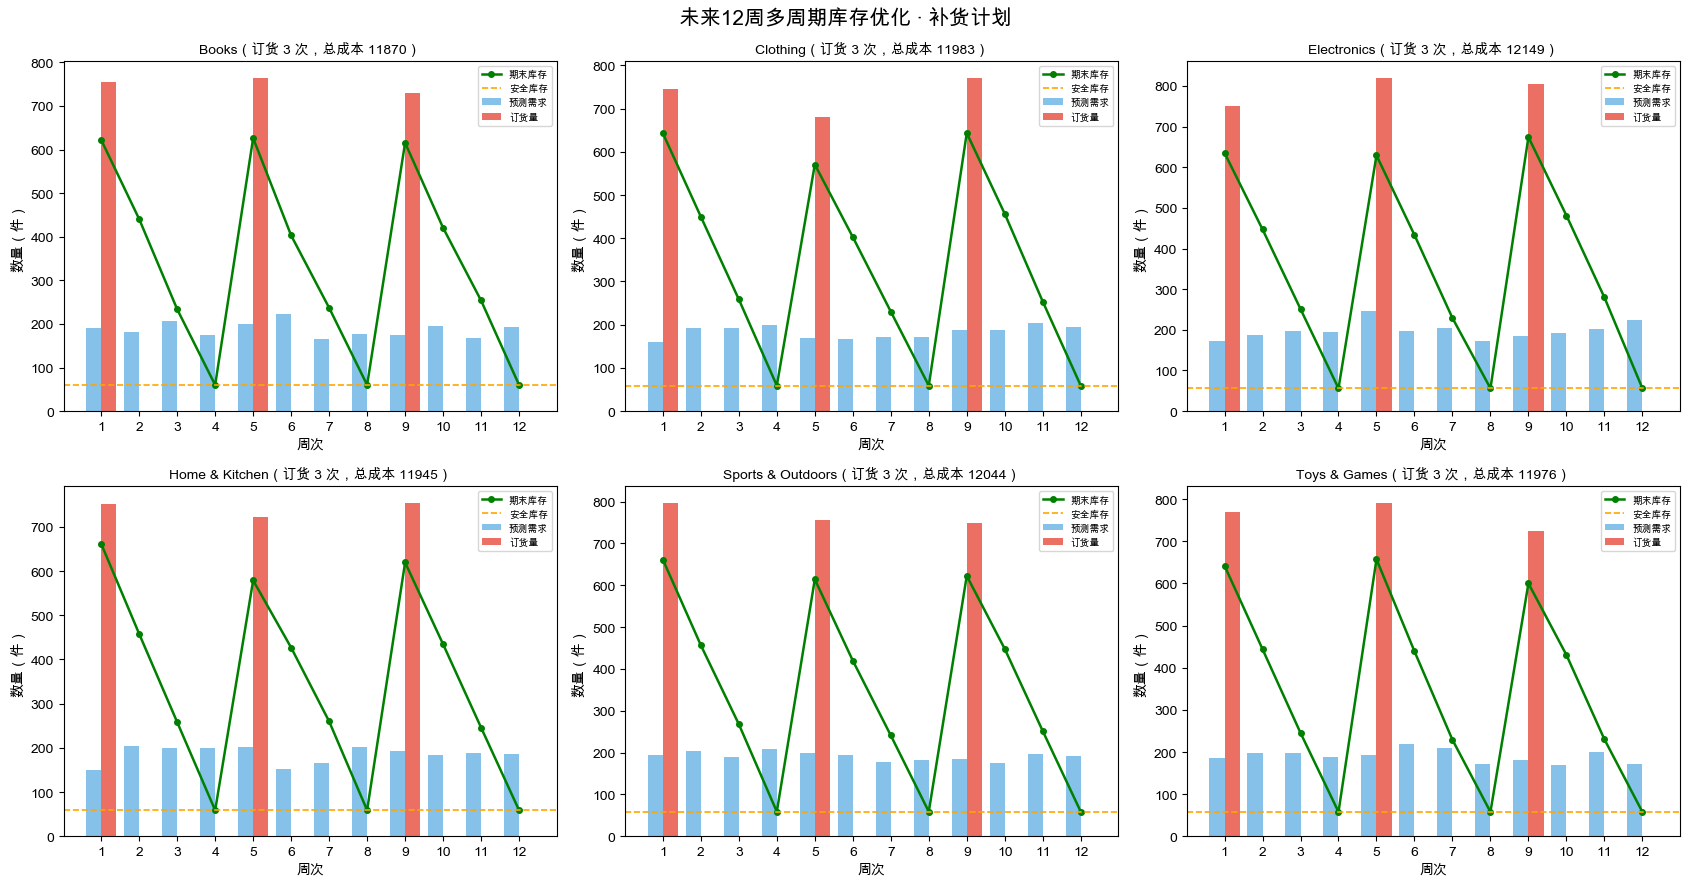

补货计划图已保存：reports/fig_w6_04_replenishment.png


In [13]:
# ── 可视化：每个品类的需求、订货、库存轨迹 ──
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('未来12周多周期库存优化 · 补货计划', fontsize=15, fontweight='bold')

x = np.arange(1, HORIZON + 1)
for i, cat in enumerate(cats):
    ax = axes[i // 3][i % 3]
    r = cat_results[cat]

    # 预测需求（浅蓝柱）
    ax.bar(x - 0.2, r['demand'], width=0.4, color='#3498db', alpha=0.6, label='预测需求')
    # 订货量（红柱）
    ax.bar(x + 0.2, r['orders'], width=0.4, color='#e74c3c', alpha=0.8, label='订货量')
    # 期末库存（绿线）
    ax.plot(x, r['inventory'], 'g-o', markersize=4, linewidth=1.8, label='期末库存')
    # 安全库存线
    ax.axhline(r['SS'], color='orange', linestyle='--', linewidth=1.2, label='安全库存')

    ax.set_title(f"{cat}（订货 {int(sum(r['flags']))} 次，总成本 {r['total_cost']:.0f}）",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('周次')
    ax.set_ylabel('数量（件）')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xticks(x)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_w6_04_replenishment.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('补货计划图已保存：reports/fig_w6_04_replenishment.png')

In [14]:
# ── 导出未来 3 个月补货计划 ──
plan_rows = []
for cat in cats:
    r = cat_results[cat]
    for t in range(HORIZON):
        plan_rows.append({
            'Category'        : cat,
            'Week'            : future_weeks[t].date(),
            'Forecast_Demand' : round(r['demand'][t]),
            'Order_Qty'       : round(r['orders'][t]),
            'End_Inventory'   : round(r['inventory'][t]),
            'Need_Order'      : '是' if r['flags'][t] > 0.5 else '',
        })

replenishment_plan = pd.DataFrame(plan_rows)

# 保存
plan_csv_path = base_path + 'replenishment_plan_3months.csv'
replenishment_plan.to_csv(plan_csv_path, index=False, encoding='utf-8-sig')
print('未来3个月补货计划已导出：', plan_csv_path)
print('共', len(replenishment_plan), '条记录（6 品类 × 12 周）\n')

# 预览：只看需要订货的周
print('===== 补货计划 · 需要下单的周次 =====')
order_weeks = replenishment_plan[replenishment_plan['Need_Order'] == '是']
print(order_weeks.to_string(index=False))

未来3个月补货计划已导出： /Users/huyujie/Documents/amazon-supply-chain-project/data/processed/replenishment_plan_3months.csv
共 72 条记录（6 品类 × 12 周）

===== 补货计划 · 需要下单的周次 =====
         Category       Week  Forecast_Demand  Order_Qty  End_Inventory Need_Order
            Books 2024-01-01              192        754            622          是
            Books 2024-01-29              199        765            626          是
            Books 2024-02-26              174        729            616          是
         Clothing 2024-01-01              161        745            643          是
         Clothing 2024-01-29              168        680            570          是
         Clothing 2024-02-26              188        772            643          是
      Electronics 2024-01-01              172        751            635          是
      Electronics 2024-01-29              248        821            629          是
      Electronics 2024-02-26              186        804            674          是
   Home

### 模块4 小结

- 使用 PuLP 构建混合整数线性规划模型，对未来 12 周（3 个月）逐周需求求解最优补货方案。
- 求解器自动权衡两类成本：批量订货可节省固定订货成本，但会推高持库成本。最优解通常表现为「集中几周下大单 + 其余周不订货」的批量补货模式。
- 各品类 12 周内安排 3 次订货，期末库存在订货周冲高后逐周消耗回落至安全库存线，全程不缺货。
- 结果已导出为 `replenishment_plan_3months.csv`，即第 6 周交付物「未来 3 个月补货计划」。
- **与 EOQ 的区别**：EOQ 假设需求恒定、给出单一订货量；多周期优化考虑需求逐周波动，给出每一周的具体订货决策，更贴近真实运营。

## 模块5：库存策略对比

在不同服务水平（90% / 95% / 99%）下，用蒙特卡洛模拟对比定期订货策略的成本与服务表现。

**模拟方法**：
- 每 3 周盘点订货一次，补货至「3 周需求 + 安全库存」
- 对每个品类的需求做 300 次随机模拟，取平均，消除单次模拟的随机噪声
- 统计四项指标：持库成本、订货成本、缺货损失、实际满足率

**核心权衡**：服务水平越高 → 安全库存越多 → 持库成本上升，但缺货损失下降。最优服务水平是让**总成本**最低的那一档。

In [15]:
# ── 参数 ──
REVIEW_PERIOD = 3      # 每 3 周盘点订货一次
N_SIM         = 300    # 每个品类模拟 300 次取平均
STOCKOUT_MULT = 2.0    # 缺货损失系数（缺货量 × 单价 × 2）

def simulate_strategy(service_level, n_sim=N_SIM):
    """蒙特卡洛模拟某服务水平下的定期订货策略"""
    z = stats.norm.ppf(service_level)
    rng = np.random.default_rng(42)
    agg = {'hold': 0, 'order': 0, 'stockout': 0, 'filled': 0, 'demand': 0}

    for cat in cats:
        wd = weekly[weekly['Category'] == cat]['Quantity']
        wmean, wstd = wd.mean(), wd.std()
        price = df[df['Category'] == cat]['UnitPrice'].mean()
        h  = price * HOLD_RATE / 52
        SS = z * wstd

        for _ in range(n_sim):
            sim_demand = rng.normal(wmean, wstd, HORIZON).clip(0)
            inv = SS
            hold = order = stockout = filled = demand = 0
            for t in range(HORIZON):
                if t % REVIEW_PERIOD == 0:                  # 盘点订货
                    inv = REVIEW_PERIOD * wmean + SS
                    order += ORDER_COST
                d = sim_demand[t]
                demand += d
                if inv >= d:
                    filled += d
                else:
                    filled   += inv
                    stockout += (d - inv) * price * STOCKOUT_MULT
                inv = max(inv - d, 0)
                hold += inv * h
            agg['hold'] += hold;   agg['order'] += order
            agg['stockout'] += stockout
            agg['filled'] += filled; agg['demand'] += demand

    for k in ['hold', 'order', 'stockout']:
        agg[k] /= n_sim
    fill_rate = agg['filled'] / agg['demand']
    return agg, fill_rate

# ── 对三档服务水平分别模拟 ──
strategy_rows = []
for name, sl in [('90%', 0.90), ('95%', 0.95), ('99%', 0.99)]:
    agg, fr = simulate_strategy(sl)
    total = agg['hold'] + agg['order'] + agg['stockout']
    strategy_rows.append({
        '目标服务水平' : name,
        '持库成本'     : round(agg['hold']),
        '订货成本'     : round(agg['order']),
        '缺货损失'     : round(agg['stockout']),
        '总成本'       : round(total),
        '实际满足率'   : round(fr * 100, 1),
    })

strategy_df = pd.DataFrame(strategy_rows)
print('===== 不同服务水平策略对比 =====')
print(strategy_df.to_string(index=False))

best = strategy_df.loc[strategy_df['总成本'].idxmin(), '目标服务水平']
print(f'\n总成本最低的策略：{best} 服务水平')

===== 不同服务水平策略对比 =====
目标服务水平  持库成本  订货成本   缺货损失    总成本  实际满足率
   90% 25066 48000 128459 201525   98.5
   95% 26327 48000  89730 164057   98.9
   99% 28753 48000  41898 118651   99.5

总成本最低的策略：99% 服务水平


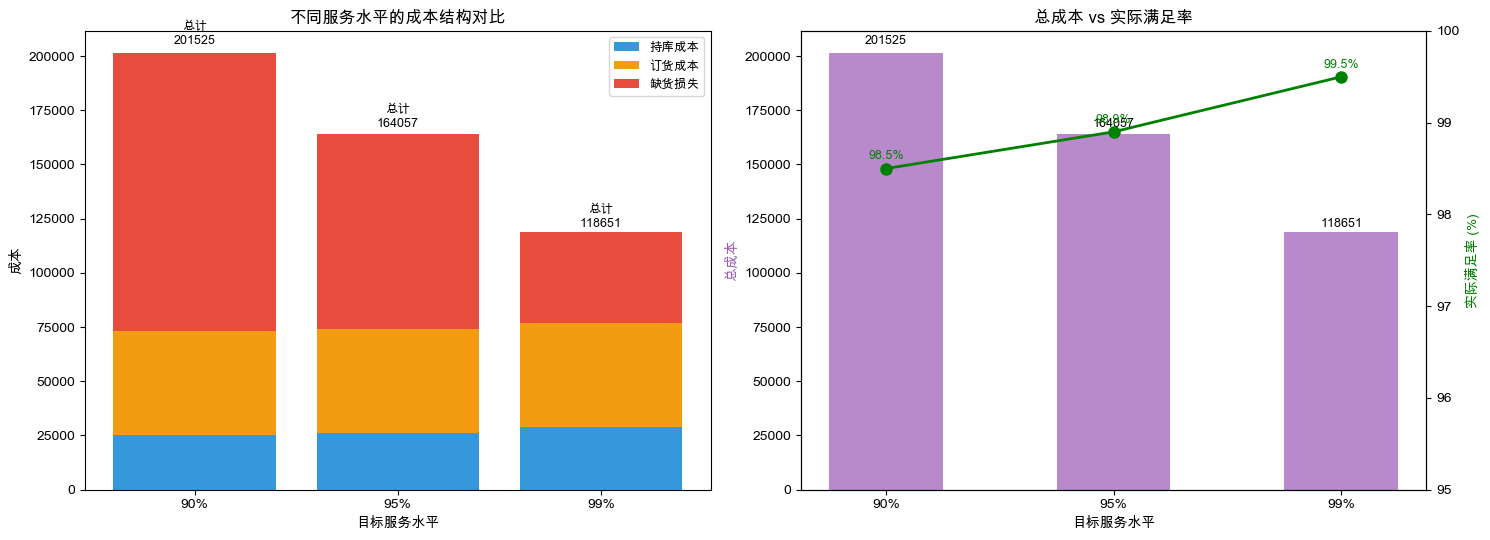

策略对比图已保存：reports/fig_w6_05_strategy_comparison.png


In [16]:
# ── 可视化：策略对比 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

labels = strategy_df['目标服务水平'].tolist()
x = np.arange(len(labels))

# 左图：成本结构堆叠柱状图
hold     = strategy_df['持库成本']
order    = strategy_df['订货成本']
stockout = strategy_df['缺货损失']

axes[0].bar(x, hold, label='持库成本', color='#3498db')
axes[0].bar(x, order, bottom=hold, label='订货成本', color='#f39c12')
axes[0].bar(x, stockout, bottom=hold + order, label='缺货损失', color='#e74c3c')

# 总成本标注
for i, total in enumerate(strategy_df['总成本']):
    axes[0].text(i, total + total*0.02, f'总计\n{total:.0f}',
                 ha='center', fontweight='bold', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('目标服务水平')
axes[0].set_ylabel('成本')
axes[0].set_title('不同服务水平的成本结构对比', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# 右图：总成本 vs 实际满足率（双轴）
ax1 = axes[1]
bars = ax1.bar(x, strategy_df['总成本'], color='#9b59b6', alpha=0.7, width=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('目标服务水平')
ax1.set_ylabel('总成本', color='#9b59b6')
for bar, v in zip(bars, strategy_df['总成本']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
             f'{v:.0f}', ha='center', fontweight='bold', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, strategy_df['实际满足率'], 'g-o', linewidth=2, markersize=8, label='实际满足率')
ax2.set_ylabel('实际满足率 (%)', color='green')
ax2.set_ylim(95, 100)
for i, fr in enumerate(strategy_df['实际满足率']):
    ax2.text(i, fr + 0.1, f'{fr}%', ha='center', color='green', fontweight='bold', fontsize=9)

axes[1].set_title('总成本 vs 实际满足率', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_w6_05_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('策略对比图已保存：reports/fig_w6_05_strategy_comparison.png')

In [17]:
# ── 导出策略对比表 ──
strategy_csv_path = base_path + 'strategy_comparison.csv'
strategy_df.to_csv(strategy_csv_path, index=False, encoding='utf-8-sig')
print('策略对比表已导出：', strategy_csv_path)

print('\n===== 库存成本与服务水平对比表 =====')
print(strategy_df.to_string(index=False))

best_row = strategy_df.loc[strategy_df['总成本'].idxmin()]
print(f"\n推荐策略：{best_row['目标服务水平']} 服务水平")
print(f"  总成本最低：{best_row['总成本']:.0f}")
print(f"  实际满足率：{best_row['实际满足率']}%")

策略对比表已导出： /Users/huyujie/Documents/amazon-supply-chain-project/data/processed/strategy_comparison.csv

===== 库存成本与服务水平对比表 =====
目标服务水平  持库成本  订货成本   缺货损失    总成本  实际满足率
   90% 25066 48000 128459 201525   98.5
   95% 26327 48000  89730 164057   98.9
   99% 28753 48000  41898 118651   99.5

推荐策略：99% 服务水平
  总成本最低：118651
  实际满足率：99.5%


### 模块5 小结

- 通过蒙特卡洛模拟（每品类 300 次取平均）对比了 90%、95%、99% 三档服务水平下的定期订货策略。
- 结果呈现清晰趋势：服务水平越高，持库成本小幅上升，但缺货损失大幅下降。
- **关键发现**：在本项目的成本结构下，缺货损失远高于持库成本，因此提高服务水平虽然增加备货，却能显著降低总成本——99% 服务水平的总成本反而最低。
- **业务建议**：当缺货损失系数较高（如热销品、客户流失成本大）时，应采用高服务水平；只有当持库成本极高（如生鲜、易贬值商品）时，才需要权衡降低服务水平。
- 对比表已导出为 `strategy_comparison.csv`，即第 6 周交付物「库存成本与服务水平对比表」。

## 第6周总结

### 完成情况

| 模块 | 内容 | 产出文件 |
|------|------|----------|
| 模块1 | ABC 库存分类 | `abc_classification.csv` |
| 模块2 | 安全库存计算（三档服务水平）| `safety_stock.csv` |
| 模块3 | 经济订货批量 EOQ | `eoq_results.csv` |
| 模块4 | 多周期库存优化（PuLP）| `replenishment_plan_3months.csv` |
| 模块5 | 库存策略对比 | `strategy_comparison.csv` |

### 交付物对照

- **库存优化代码**：本 Notebook（模块1~5 全部代码）
- **ABC 分类结果报告**：模块1 + `abc_classification.csv`
- **库存成本与服务水平对比表**：模块5 + `strategy_comparison.csv`
- **未来 3 个月补货计划**：模块4 + `replenishment_plan_3months.csv`

### 核心结论

1. **分级管理**：A 类 SKU 直接影响营收，应采用高服务水平、高频盘点；C 类可粗放管理。
2. **补货模式**：多周期优化求解器自动选择「批量订货」——集中几周下大单，平时库存压在安全库存线，平衡固定订货成本与持库成本。
3. **服务水平权衡**：本项目缺货损失远高于持库成本，提高服务水平反而降低总成本，推荐 99% 服务水平。

### 方法局限与改进方向

- 需求预测采用历史同期均值，较为简化；可接入第5周的集成预测模型提升精度。
- 提前期假设为固定值；真实供应链中提前期本身存在波动，可进一步建模。
- 优化在品类层级进行；后续可细化到 SKU 层级，但需考虑求解规模。